In [1]:
import numpy as np
from sklearn.datasets import make_moons
import scipy as sp
from DataVisualization import Plot2DLinearClassifier, PlotBinaryClassData
import seaborn as sns

from typing import Callable, List, Tuple
from numpy.typing import NDArray

In [2]:
# Parameters
numSamples = 500
noise_level = 0.1
numGridPts = 250

In [3]:
mX, vY = make_moons(n_samples= numSamples, noise= noise_level)
print(f'Shape of feature matrix: {mX.shape}')
print(f'Vector of labels shape: {vY.shape}')

Shape of feature matrix: (500, 2)
Vector of labels shape: (500,)


In [4]:
vY[vY == 0] = -1
vU, counts = np.unique(vY, return_counts=True)
print(vU, counts)


[-1  1] [250 250]


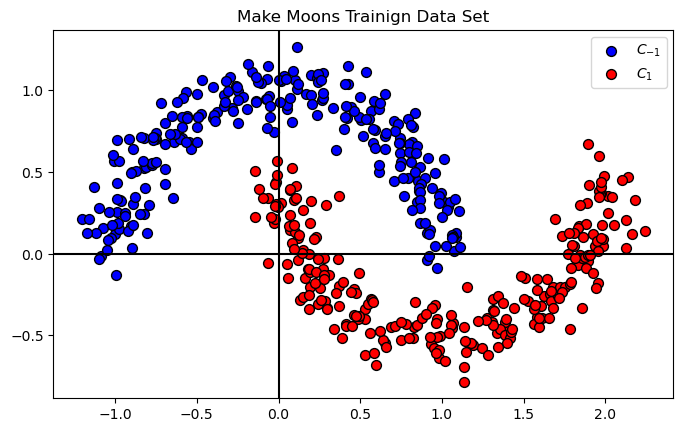

In [5]:
hA = PlotBinaryClassData(mX, vY, axisTitle="Make Moons Trainign Data Set")

In [6]:
# adding of -1 coumn into the mx
mX = np.column_stack((-np.ones(numSamples), mX))
print(f'the shape of mX : {mX.shape}')
mX[0]

the shape of mX : (500, 3)


array([-1.        ,  1.27270049, -0.39187122])

In [7]:
# Functions:

# shifted sigmoid function from -1 to 1 
def SigmoidFun(vX: NDArray) -> NDArray:
    return (2 * sp.special.expit(vX)) - 1

def GradSigmoidFun(vX:NDArray) -> NDArray:
    vExpit = sp.special.expit(vX)
    return 2 * vExpit * (1 - vExpit)

def LossFun(vW, mX, vY):
    # number of rows in mX, num of samples  
    numSamples = mX.shape[0]
    vR = SigmoidFun(mX @ vW) - vY
    return np.sum(np.square(vR)) / (4 * numSamples)

def GradLossFun(vW, mX, vY):
    numSamples = mX.shape[0]
    return (mX.T * GradSigmoidFun(mX @ vW).T) @ (SigmoidFun(mX @ vW) -vY) / (2 * numSamples)

def CalcAccuracy(vW, mX, vY):
    vHatY = np.sign(mX @ vW)
    return np.mean(vHatY = vY)

In [8]:
K = 1500 # number of steps
mu = 0.1 # step size
vW = np.array([0.0, -1.0, 2.0]) #initial weight

mW = np.zeros(shape=(vW.shape[0], K)) # fat matrix, number of rows is 3, number of column as a number of steps
vE = np.full(shape= K, fill_value=None) # vector of None values with lenth of number of steps, ready to get error value from every step
vL = np.full(shape= K, fill_value=None) # same, vector to get loss function values in every step

vHatY = np.sign(mX @ vW)
# Assigning initial values
mW[:, 0] = vW # first column get the vW values(initial weights)
vE[0] = np.mean(vHatY != vY)
vL[0] = LossFun(vW, mX, vY)

for kk in range(1, K): # from 1 because the zero index is already assigned
    vW = vW - mu * GradLossFun(vW, mX, vY) # Update of weights step in direction of negative gradient of Loss function
    mW[:, kk] = vW #update if matric of weights
    vHatY = np.sign(mX @ vW) # prediction of classes
    vE[kk] = np.mean(vHatY != vY)
    vL[kk] = LossFun(vW, mX, vY)

In [ ]:
import matplotlib.pyplot as plt

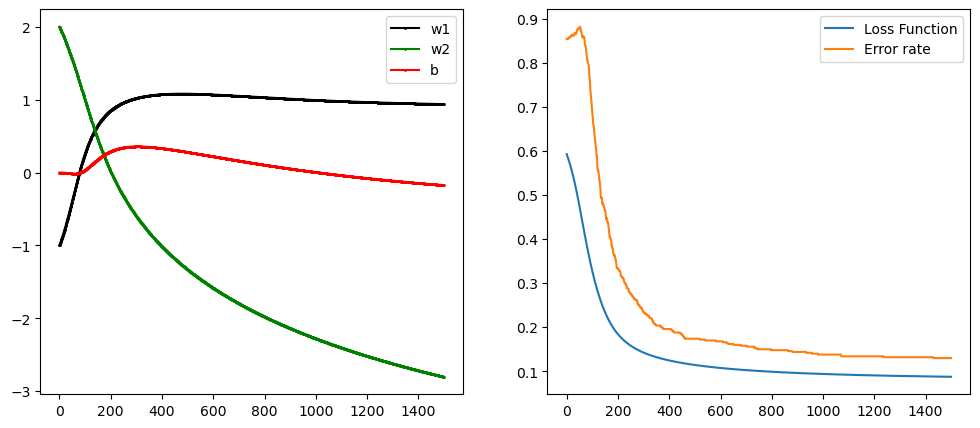

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5))
ax[0].plot(range(K), mW[1], marker = 'o', markersize=1, color='black', label='w1')
ax[0].plot(range(K), mW[2], marker = 'o', markersize=1, color='green', label='w2')
ax[0].plot(range(K), mW[0], marker = 'o', markersize=1, color='red', label='b')
ax[0].legend()

ax[1].plot(range(K), vL, label='Loss Function')
ax[1].plot(range(K), vE, label= 'Error rate')
ax[1].legend()
plt.show()

In [ ]:
X = np.linspace(-3, 3, 11)
Y = -(mW[1, -1] / mW[2, -1]) * vX + mW[0, -1] / mW[2, -1]

NameError: name 'vX' is not defined